# Hybrid Quantum-Classical Reinforcement Learning (3/3)

___
___

## Introduction
___

This series of experiments is based on the 2025 paper by Nagy et al.: "[Hybrid Quantum-Classical Reinforcement Learning in Latent Observation Spaces](https://arxiv.org/abs/2410.18284)".

In this article, the authors apply hybrid quantum-classical Reinforcement Learning (RL) models to two simulated environments. They compare classical, qubit-based and photonic-based agents, all using Proximal Policy Optimization (PPO). They also use an AutoEncoder (AE) to compress the dimensionality of the observations and train that AE jointly with the PPO agents.

The notebook series aims to compare the resources cost of the different systems to reach the same performance. It is divided in three parts:

- [Part I: Classical vs Qubit agents on the Cart Pole environment](QRL_experiment_1.ipynb)
- [Part II: Classical vs Qubit agents on the Lunar Lander and Car Racing environments](QRL_experiment_2.ipynb)
- **Part III: Photonic agents on the three environments**

This third notebook will present:
1. Photonic-based PPO
2. The reused code from the first notebook
3. Results
4. Conclusions

In [1]:
import os
import random
import datetime
from itertools import count
from collections import deque
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import gymnasium as gym
import pennylane as qp

from ipynb.fs.defs.QRL_experiment_1 import AutoEncoder, PPO, CriticNN, MemoryTracker, count_parameters, save_results, plot_results
from ipynb.fs.defs.QRL_experiment_2 import ConvolutionalAE, CarRacingPPO, CriticCNN

# For reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)

## 1 - Photonic-based PPO
___

CV PPO (Non linear with deprecated SF and Piquasso)

The last one brings non-linearity, however, with PennyLane's Gaussian simulator, it is not possible to obtain. One would have to use Strawberry-Fields backend which is no longer maintained. So we will use the linear solution in this notebook.

The photonic quantum circuit used in the article is composed of squeezing, displacement, rotation and Kerr gates. 
Continuous variable

Photonic only in the 3 environments.

In [2]:
# Create the environments
cartpole_env = gym.make("CartPole-v1", render_mode="rgb_array")
cartpole_env.reset(seed=seed)
cartpole_env.action_space.seed(seed)
cartpole_env.observation_space.seed(seed)

lunarlander_env = gym.make("LunarLander-v3", render_mode="rgb_array")
lunarlander_env.reset(seed=seed)
lunarlander_env.action_space.seed(seed)
lunarlander_env.observation_space.seed(seed)

carracing_env = gym.make("CarRacing-v3", render_mode="rgb_array", continuous=False)
carracing_env.reset(seed=seed)
carracing_env.action_space.seed(seed)
carracing_env.observation_space.seed(seed)

42

In [3]:
class ActorPhotonicNN(nn.Module):
    def __init__(self, input_shape, intermediate_dim, output_dim):
        super().__init__()
        n_modes = input_shape
        n_layers = intermediate_dim

        shapes = qp.CVNeuralNetLayers.shape(n_layers=n_layers, n_wires=n_modes)
        weight_shapes = {
            name: shape for name, shape in zip(
                ["theta_1", "phi_1", "varphi_1", "r", "phi_r",
                 "theta_2", "phi_2", "varphi_2", "a", "phi_a", "k"],
                shapes,
            )
        }
        
        dev = qp.device("strawberryfields.fock", wires=n_modes, cutoff_dim=10)

        self.device = torch.device(
            "cuda" if torch.cuda.is_available() else
            "cpu"
        )

        @qp.qnode(dev, interface="torch")
        def qnode(inputs, **weights):
            qp.templates.embeddings.DisplacementEmbedding(inputs, wires=range(n_modes))
            qp.CVNeuralNetLayers(*weights.values(), wires=range(n_modes))
            return [qp.expval(qp.X(i)) for i in range(n_modes)]

        self.qlayer1 = qp.qnn.TorchLayer(qnode, weight_shapes)
        self.layer1 = nn.Linear(n_modes, output_dim).to(self.device)

    def forward(self, x):
        x = self.qlayer1(x.cpu()).to(self.device)
        x = self.layer1(x)
        return x
    
results_folder = "results"
os.makedirs(results_folder, exist_ok=True)
results_filepath = os.path.join(results_folder, "qrl_results.json")

### Cart Pole

In [4]:
env_name = "Cart Pole"
cp_config = {
    "ae_hidden_dim": 32, "ae_output_dim": 1,
    "critic_intermediate_dim": 64, "minibatch_size": 128, "lr": 1e-3,
    "K": 10, "episode_update_frequency": 1, "mean_reward_lookback": 20, "mean_reward_stop": 480,
    "gamma": 0.98, "lambda": 0.8, "epsilon": 0.2, "entropy_coeff": 0.0
    }
cp_config["actor_intermediate_dim"] = 1
with MemoryTracker("Photonic PPO") as cp_photonic_stats:
    cp_photonic_ppo = PPO(AutoEncoderClass=AutoEncoder, ActorClass=ActorPhotonicNN, CriticClass=CriticNN, env=cartpole_env, config=cp_config)
    cp_photonic_parameters = count_parameters(cp_photonic_ppo.actor)
    cp_photonic_mean_rewards, cp_photonic_training_time = cp_photonic_ppo.run()
photonic_results = { 
    "training_time": cp_photonic_training_time, 
    "mean_rewards": cp_photonic_mean_rewards, 
    "parameters": cp_photonic_parameters, 
    "memory": cp_photonic_stats.peak_rss_mb
}
torch.save(cp_photonic_ppo.autoencoder.state_dict(), os.path.join(results_folder, "cp_photonic_ae.pt"))
torch.save(cp_photonic_ppo.actor.state_dict(), os.path.join(results_folder, "cp_photonic_actor.pt"))
torch.save(cp_photonic_ppo.critic.state_dict(), os.path.join(results_folder, "cp_photonic_critic.pt"))
qrl_results = save_results(results_filepath, env_name, "photonic", photonic_results)


Step 500: mean reward = 12.30 (0:00:24.043039)

Step 1000: mean reward = 11.70 (0:00:22.748267)

Step 1500: mean reward = 11.30 (0:00:21.750464)

Step 2000: mean reward = 10.60 (0:00:20.789642)

Step 2500: mean reward = 11.65 (0:00:20.602513)

Step 3000: mean reward = 12.65 (0:00:20.479559)

Step 3500: mean reward = 14.85 (0:00:20.781203)

Step 4000: mean reward = 16.05 (0:00:20.791645)

Step 4500: mean reward = 17.60 (0:00:20.694617)

Step 5000: mean reward = 18.75 (0:00:20.818104)

Step 5500: mean reward = 24.50 (0:00:20.890689)

Step 6000: mean reward = 30.50 (0:00:20.786976)

Step 6500: mean reward = 41.35 (0:00:20.455695)

Step 7000: mean reward = 40.25 (0:00:17.512599)

Step 7500: mean reward = 42.55 (0:00:19.332478)

Step 8000: mean reward = 50.50 (0:00:19.208346)

Step 8500: mean reward = 63.35 (0:00:20.175464)

Step 9000: mean reward = 74.75 (0:00:18.896162)

Step 9500: mean reward = 84.35 (0:00:19.126678)

Step 10000: mean reward = 97.15 (0:00:19.547441)

Step 10500: mean re

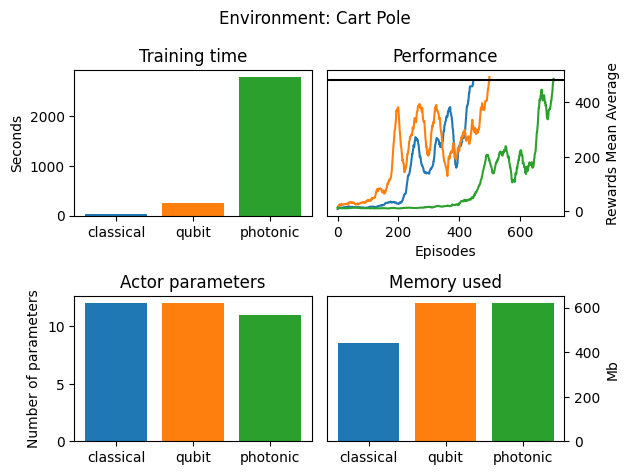

In [5]:
plot_results(env_name, qrl_results[env_name], cp_config["mean_reward_stop"], methods=["classical", "qubit", "photonic"])

### Lunar Lander

In [6]:
env_name = "Lunar Lander"
ll_config = {
    "ae_hidden_dim": 64, "ae_output_dim": 2,
    "critic_intermediate_dim": 128,
    "minibatch_size": 64, "lr": 3e-4,
    "K": 4, "episode_update_frequency": 1, "mean_reward_lookback": 50, "mean_reward_stop": 220,
    "gamma": 0.99, "lambda": 0.98, "epsilon": 0.2, "entropy_coeff": 0.01
    }

ll_config["actor_intermediate_dim"] = 1
with MemoryTracker("Photonic PPO") as ll_photonic_stats:
    ll_photonic_ppo = PPO(AutoEncoderClass=AutoEncoder, ActorClass=ActorPhotonicNN, CriticClass=CriticNN, env=lunarlander_env, config=ll_config)
    ll_photonic_parameters = count_parameters(ll_photonic_ppo.actor)
    ll_photonic_mean_rewards, ll_photonic_training_time = ll_photonic_ppo.run()
photonic_results = { 
    "training_time": ll_photonic_training_time, 
    "mean_rewards": ll_photonic_mean_rewards, 
    "parameters": ll_photonic_parameters, 
    "memory": ll_photonic_stats.peak_rss_mb
}
torch.save(ll_photonic_ppo.autoencoder.state_dict(), os.path.join(results_folder, "ll_photonic_ae.pt"))
torch.save(ll_photonic_ppo.actor.state_dict(), os.path.join(results_folder, "ll_photonic_actor.pt"))
torch.save(ll_photonic_ppo.critic.state_dict(), os.path.join(results_folder, "ll_photonic_critic.pt"))
qrl_results = save_results(results_filepath, env_name, "photonic", photonic_results)


Step 1000: mean reward = -244.86 (0:01:25.894701)

Step 2000: mean reward = -231.68 (0:01:25.161674)

Step 3000: mean reward = -247.56 (0:01:25.148131)

Step 4000: mean reward = -253.71 (0:01:25.073545)

Step 5000: mean reward = -239.74 (0:01:24.933254)

Step 6000: mean reward = -264.66 (0:01:24.923933)

Step 7000: mean reward = -258.72 (0:01:25.167961)

Step 8000: mean reward = -262.52 (0:01:24.942287)

Step 9000: mean reward = -254.54 (0:01:25.073320)

Step 10000: mean reward = -242.91 (0:01:25.284584)

Step 11000: mean reward = -212.98 (0:01:25.162248)

Step 12000: mean reward = -216.97 (0:01:25.118743)

Step 13000: mean reward = -197.33 (0:01:27.889316)

Step 14000: mean reward = -206.57 (0:01:26.483033)

Step 15000: mean reward = -213.91 (0:01:23.403273)

Step 16000: mean reward = -229.16 (0:01:23.651579)

Step 17000: mean reward = -241.26 (0:01:23.590038)

Step 18000: mean reward = -250.10 (0:01:23.647179)

Step 19000: mean reward = -236.90 (0:01:23.212699)

Step 20000: mean rew

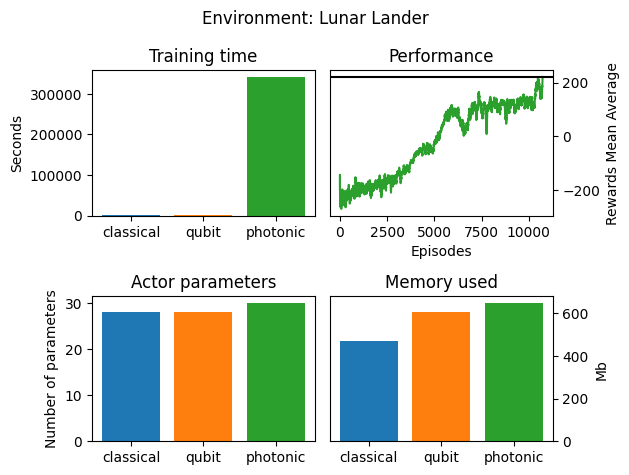

In [7]:
plot_results(env_name, qrl_results[env_name], ll_config["mean_reward_stop"], methods=["classical", "qubit", "photonic"])

### Car Racing

In [8]:
env_name = "Car Racing"
cr_config = {
    "image_size": 64, "stacked_states_size": 2,
    "ae_hidden_dims": [16, 32, 64, 256], "ae_output_dim": 3, 
    "ae_pretrain_epochs": 300, "ae_pretrain_batchsize": 64,
    "critic_intermediate_dim": [16, 32, 64, 256],
    "minibatch_size": 128, "lr": 1e-4,
    "K": 8, "episode_update_frequency": 4, "mean_reward_lookback": 30, "mean_reward_stop": 850,
    "gamma": 0.99, "lambda": 0.95, "epsilon": 0.2, "entropy_coeff": 0.01
    }
custom_obs_shape = (cr_config["image_size"], cr_config["image_size"], cr_config["stacked_states_size"])
cr_config["actor_intermediate_dim"] = 2
with MemoryTracker("Photonic PPO") as cr_photonic_stats:
    cr_photonic_ppo = CarRacingPPO(AutoEncoderClass=ConvolutionalAE, ActorClass=ActorPhotonicNN, CriticClass=CriticCNN, env=carracing_env, config=cr_config, custom_obs_shape=custom_obs_shape)
    cr_photonic_parameters = count_parameters(cr_photonic_ppo.actor)
    cr_photonic_mean_rewards, cr_photonic_training_time = cr_photonic_ppo.run()
photonic_results = { 
    "training_time": cr_photonic_training_time, 
    "mean_rewards": cr_photonic_mean_rewards, 
    "parameters": cr_photonic_parameters, 
    "memory": cr_photonic_stats.peak_rss_mb
}
torch.save(cr_photonic_ppo.autoencoder.state_dict(), os.path.join(results_folder, "cr_photonic_ae.pt"))
torch.save(cr_photonic_ppo.actor.state_dict(), os.path.join(results_folder, "cr_photonic_actor.pt"))
torch.save(cr_photonic_ppo.critic.state_dict(), os.path.join(results_folder, "cr_photonic_critic.pt"))
qrl_results = save_results(results_filepath, env_name, "photonic", photonic_results)

  peak process RSS :   1708.3 MB  (Δ +1248.0 MB)
  peak MPS allocated (polled):      0.0 MB


KeyboardInterrupt: 

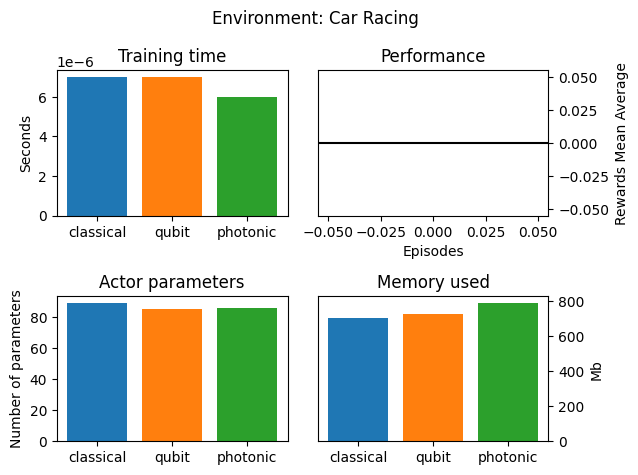

In [ ]:
plot_results(env_name, qrl_results[env_name], cr_config["mean_reward_stop"], methods=["classical", "qubit", "photonic"])

### Conclusion
How does it compare to classical and Qubit??